# Qwen3-VL-4B


# Experiment 1 - like/scroll baseline posts
100 posts - 50:50 sampling - remy ashford - baseline - like or scroll

In [1]:
# This installs torch 2.6.0 and torchvision 0.21.0 pinned to cu124 because the
# GPU server's NVIDIA driver supports CUDA 12.4 but not CUDA 13.0. torchaudio is
# explicitly uninstalled and excluded because it is not needed for Qwen3-VL and
# its cu124 build conflicts with the server's CUDA 13 runtime libraries, causing
# an OSError on import. transformers is installed from source because Qwen3-VL
# support is not yet available in a stable PyPI release.

import sys, subprocess

# Uninstall torchaudio if it exists from a previous session
subprocess.run([sys.executable, "-m", "pip", "uninstall", "torchaudio", "-y"])

# Install torch stack (no torchaudio)
subprocess.run([sys.executable, "-m", "pip", "install",
    "torch==2.6.0", "torchvision==0.21.0",
    "--index-url", "https://download.pytorch.org/whl/cu124",
    "--user", "-q"], check=True)

# Install transformers + dependencies
subprocess.run([sys.executable, "-m", "pip", "install",
    "git+https://github.com/huggingface/transformers",
    "accelerate", "qwen-vl-utils",
    "--user", "-q"], check=True)

print("✅ Done — restart the kernel now")

✅ Done — restart the kernel now


Restart kernel after running above cell

In [2]:
!nvidia-smi

Sat Jun 13 18:10:41 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.08             Driver Version: 550.127.08     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:C6:00.0 Off |                   On |
| N/A   33C    P0             79W /  700W |                  N/A   |     N/A      Default |
|                                         |                        |              Enabled |
+-----------------------------------------+-----

1) Run export HF_TOKEN= hf_... on terminal in order to avoid including it in the notebook before loading a model
2) Run loading of model twice so it actually picks up the token

In [6]:
import sys
sys.path.append("/home/jovyan")

from config_hf_token import HF_TOKEN
from huggingface_hub import login

login(token=HF_TOKEN)

In [7]:
import torch
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-4B-Instruct")

model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-4B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

print("✅ Loaded successfully")

Using device: cuda


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

✅ Loaded successfully


In [8]:
print(torch.cuda.get_device_name(0))
print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"VRAM free: {torch.cuda.memory_reserved(0) / 1e9:.1f} GB reserved")

NVIDIA H100 80GB HBM3 MIG 4g.40gb
VRAM total: 42.3 GB
VRAM free: 8.9 GB reserved


In [9]:
import sys
from pathlib import Path

ROOT_DIR = Path().resolve().parents[2]          # project root
sys.path.append(str(ROOT_DIR / "experiments"))  # so we can import experiments/utils/

# 1) Baseline - Gender neutral user

## Creating the paired sample

In [10]:
from utils.sampling import build_paired_sample

# --- Configuration ---
EXPERIMENT_DIR = Path().resolve().parent        # experiments/e1/
OUTPUT_DIR = Path().resolve() / "outputs"       # experiments/e1/qwen3-8b-vl/outputs/
SEED = 42
SAMPLE_SIZE = 50

# --- Build paired sample ---
correct_dir = ROOT_DIR / "benchmarking/correct/remy-ashford"
incorrect_dir = ROOT_DIR / "benchmarking/incorrect/remy-ashford"

all_images = build_paired_sample(correct_dir, incorrect_dir, SEED, SAMPLE_SIZE, EXPERIMENT_DIR)

📋 Loading existing selection from /home/jovyan/experiments/e1/selected_images.json
✅ All selected numbers verified in both correct and incorrect folders.
Selected 50 pairs → 100 images total


In [11]:
import importlib
import utils.e1_optimized as e1_optimized_module
importlib.reload(e1_optimized_module)

from utils.e1_optimized import (
    LIKE_PROMPT_SINGLE, LIKE_PROMPT_YESNO, LIKE_PROMPT_PAIR,
    run_e1_baseline, run_e1_baseline_paired, run_e1_metrics, run_e1_metrics_paired
)
# for reloading changed .py file
import importlib
import utils.e1_analysis_optimized as e1_analysis_module
importlib.reload(e1_analysis_module)

from utils.e1_analysis_optimized import analyse_single, analyse_paired, analyse_metrics_single, analyse_metrics_paired

OUTPUT_DIR = Path().resolve() / "outputs"

## Approach 1: like or scroll - single image

In [12]:
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_baseline.json")

✅ 001_correct → like
✅ 001_incorrect → like
✅ 003_correct → like
✅ 003_incorrect → like
✅ 004_correct → like
✅ 004_incorrect → like
✅ 005_correct → like
✅ 005_incorrect → like
✅ 006_correct → like
✅ 006_incorrect → like
✅ 007_correct → like
✅ 007_incorrect → like
✅ 012_correct → like
✅ 012_incorrect → like
✅ 014_correct → like
✅ 014_incorrect → like
✅ 015_correct → like
✅ 015_incorrect → like
✅ 017_correct → like
✅ 017_incorrect → like
✅ 018_correct → like
✅ 018_incorrect → like
✅ 020_correct → like
✅ 020_incorrect → like
✅ 021_correct → like
✅ 021_incorrect → like
✅ 023_correct → like
✅ 023_incorrect → like
✅ 025_correct → like
✅ 025_incorrect → like
✅ 026_correct → like
✅ 026_incorrect → like
✅ 028_correct → like
✅ 028_incorrect → like
✅ 029_correct → like
✅ 029_incorrect → like
✅ 030_correct → like
✅ 030_incorrect → like
✅ 032_correct → like
✅ 032_incorrect → like
✅ 036_correct → like
✅ 036_incorrect → like
✅ 039_correct → like
✅ 039_incorrect → like
✅ 044_correct → like
✅ 044_incor

In [13]:
# Approach 1
# single like/scroll
analyse_single(OUTPUT_DIR, "e1_results_baseline.json", like_answer="like")



Single image analysis: e1_results_baseline
=== Summary ===


,metric,value
0,overall_like_rate_%,100.0
1,like_rate_correct_%,100.0
2,like_rate_incorrect_%,100.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,like
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
2,003_correct,correct,You are shown a social media post.\nYou can ei...,like
3,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
4,004_correct,correct,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...
95,096_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
96,098_correct,correct,You are shown a social media post.\nYou can ei...,like
97,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
98,100_correct,correct,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_baseline.csv


## Approach 1: YES/NO variant

In [14]:
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_baseline_yesno.json")


✅ 001_correct → yes
✅ 001_incorrect → yes
✅ 003_correct → yes
✅ 003_incorrect → yes
✅ 004_correct → yes
✅ 004_incorrect → yes
✅ 005_correct → yes
✅ 005_incorrect → yes
✅ 006_correct → yes
✅ 006_incorrect → yes
✅ 007_correct → yes
✅ 007_incorrect → yes
✅ 012_correct → yes
✅ 012_incorrect → yes
✅ 014_correct → yes
✅ 014_incorrect → yes
✅ 015_correct → yes
✅ 015_incorrect → yes
✅ 017_correct → yes
✅ 017_incorrect → yes
✅ 018_correct → yes
✅ 018_incorrect → yes
✅ 020_correct → yes
✅ 020_incorrect → yes
✅ 021_correct → yes
✅ 021_incorrect → yes
✅ 023_correct → yes
✅ 023_incorrect → yes
✅ 025_correct → yes
✅ 025_incorrect → yes
✅ 026_correct → yes
✅ 026_incorrect → yes
✅ 028_correct → yes
✅ 028_incorrect → yes
✅ 029_correct → yes
✅ 029_incorrect → yes
✅ 030_correct → yes
✅ 030_incorrect → yes
✅ 032_correct → yes
✅ 032_incorrect → yes
✅ 036_correct → yes
✅ 036_incorrect → yes
✅ 039_correct → yes
✅ 039_incorrect → yes
✅ 044_correct → yes
✅ 044_incorrect → yes
✅ 047_correct → yes
✅ 047_incorrec

In [15]:
analyse_single(OUTPUT_DIR, "e1_results_baseline_yesno.json", like_answer="yes")


Single image analysis: e1_results_baseline_yesno
=== Summary ===


,metric,value
0,overall_yes_rate_%,100.0
1,yes_rate_correct_%,100.0
2,yes_rate_incorrect_%,100.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,yes
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,yes
2,003_correct,correct,You are shown a social media post.\nYou can ei...,yes
3,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,yes
4,004_correct,correct,You are shown a social media post.\nYou can ei...,yes
...,...,...,...,...
95,096_incorrect,incorrect,You are shown a social media post.\nYou can ei...,yes
96,098_correct,correct,You are shown a social media post.\nYou can ei...,yes
97,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,yes
98,100_correct,correct,You are shown a social media post.\nYou can ei...,yes


✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_baseline_yesno.csv


## Approach 2: A/B testing - paired images

In [16]:
print(f"\n{'='*60}\nApproach 2: paired A/B\n{'='*60}")
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]
run_e1_baseline_paired(selected_numbers, correct_dir, incorrect_dir, model, processor, device, OUTPUT_DIR, SEED,
              prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_baseline_paired.json")




Approach 2: paired A/B
✅ Pair 001 → liked correct (answered A)
✅ Pair 003 → liked incorrect (answered B)
✅ Pair 004 → liked incorrect (answered A)
✅ Pair 005 → liked correct (answered A)
✅ Pair 006 → liked incorrect (answered A)
✅ Pair 007 → liked correct (answered A)
✅ Pair 012 → liked correct (answered B)
✅ Pair 014 → liked correct (answered B)
✅ Pair 015 → liked incorrect (answered B)
✅ Pair 017 → liked incorrect (answered B)
✅ Pair 018 → liked correct (answered A)
✅ Pair 020 → liked incorrect (answered A)
✅ Pair 021 → liked incorrect (answered B)
✅ Pair 023 → liked incorrect (answered B)
✅ Pair 025 → liked correct (answered A)
✅ Pair 026 → liked correct (answered B)
✅ Pair 028 → liked correct (answered B)
✅ Pair 029 → liked correct (answered A)
✅ Pair 030 → liked correct (answered A)
✅ Pair 032 → liked correct (answered B)
✅ Pair 036 → liked incorrect (answered A)
✅ Pair 039 → liked incorrect (answered A)
✅ Pair 044 → liked incorrect (answered A)
✅ Pair 047 → liked incorrect (answ

In [17]:
analyse_paired(OUTPUT_DIR, "e1_results_baseline_paired.json")


Paired A/B analysis: e1_results_baseline_paired
=== Summary ===


,metric,value
0,liked_correct_%,36.0
1,liked_incorrect_%,64.0
2,invalid_answer_%,0.0


=== Per Pair Results ===


,num,post_a_variant,post_b_variant,prompt,answer,liked_variant
0,001,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
1,003,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect
2,004,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
3,005,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
4,006,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
5,007,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
6,012,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
7,014,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
8,015,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect
9,017,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect


✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_baseline_paired.csv


# Likes only - Gender neutral user

In [18]:
"""
import os
os.chdir('/home/jovyan/benchmarking')
!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only
!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only
"""

"\nimport os\nos.chdir('/home/jovyan/benchmarking')\n!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only\n!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only\n"

## Approach 1: like or scroll - single image

In [19]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_likes_only.json")


✅ 001_correct_10 → like
✅ 001_incorrect_10 → like
✅ 003_correct_10 → like
✅ 003_incorrect_10 → like
✅ 004_correct_10 → like
✅ 004_incorrect_10 → like
✅ 005_correct_10 → like
✅ 005_incorrect_10 → like
✅ 006_correct_10 → like
✅ 006_incorrect_10 → like
✅ 007_correct_10 → like
✅ 007_incorrect_10 → like
✅ 012_correct_10 → like
✅ 012_incorrect_10 → like
✅ 014_correct_10 → like
✅ 014_incorrect_10 → like
✅ 015_correct_10 → like
✅ 015_incorrect_10 → like
✅ 017_correct_10 → like
✅ 017_incorrect_10 → like
✅ 018_correct_10 → like
✅ 018_incorrect_10 → like
✅ 020_correct_10 → like
✅ 020_incorrect_10 → like
✅ 021_correct_10 → like
✅ 021_incorrect_10 → like
✅ 023_correct_10 → like
✅ 023_incorrect_10 → like
✅ 025_correct_10 → like
✅ 025_incorrect_10 → like
✅ 026_correct_10 → like
✅ 026_incorrect_10 → like
✅ 028_correct_10 → like
✅ 028_incorrect_10 → like
✅ 029_correct_10 → like
✅ 029_incorrect_10 → like
✅ 030_correct_10 → like
✅ 030_incorrect_10 → like
✅ 032_correct_10 → like
✅ 032_incorrect_10 → like


In [20]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only.json", like_answer="like")


Metrics single image analysis: e1_results_likes_only
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,100.0
1,like_rate_correct_%,100.0
2,like_rate_incorrect_%,100.0


=== Rate per Scale Value ===


/home/jovyan/experiments/utils/e1_analysis_optimized.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,100.0,100.0,100.0,100.0
1,100,100.0,100.0,100.0,100.0
2,1000,100.0,100.0,100.0,100.0
3,10000,100.0,100.0,100.0,100.0
4,100000,100.0,100.0,100.0,100.0
5,1000000,100.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,like
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,like
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,like
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,like
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_likes_only.csv


## Approach 1: YES/NO variant

In [21]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_likes_only_yesno.json")


✅ 001_correct_10 → yes
✅ 001_incorrect_10 → yes
✅ 003_correct_10 → yes
✅ 003_incorrect_10 → yes
✅ 004_correct_10 → yes
✅ 004_incorrect_10 → yes
✅ 005_correct_10 → yes
✅ 005_incorrect_10 → yes
✅ 006_correct_10 → yes
✅ 006_incorrect_10 → yes
✅ 007_correct_10 → yes
✅ 007_incorrect_10 → yes
✅ 012_correct_10 → yes
✅ 012_incorrect_10 → yes
✅ 014_correct_10 → yes
✅ 014_incorrect_10 → yes
✅ 015_correct_10 → yes
✅ 015_incorrect_10 → yes
✅ 017_correct_10 → yes
✅ 017_incorrect_10 → yes
✅ 018_correct_10 → yes
✅ 018_incorrect_10 → yes
✅ 020_correct_10 → yes
✅ 020_incorrect_10 → yes
✅ 021_correct_10 → yes
✅ 021_incorrect_10 → yes
✅ 023_correct_10 → yes
✅ 023_incorrect_10 → yes
✅ 025_correct_10 → yes
✅ 025_incorrect_10 → yes
✅ 026_correct_10 → yes
✅ 026_incorrect_10 → yes
✅ 028_correct_10 → yes
✅ 028_incorrect_10 → yes
✅ 029_correct_10 → yes
✅ 029_incorrect_10 → yes
✅ 030_correct_10 → yes
✅ 030_incorrect_10 → yes
✅ 032_correct_10 → yes
✅ 032_incorrect_10 → yes
✅ 036_correct_10 → yes
✅ 036_incorrect_1

In [22]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_likes_only_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,100.0
1,yes_rate_correct_%,100.0
2,yes_rate_incorrect_%,100.0


=== Rate per Scale Value ===


/home/jovyan/experiments/utils/e1_analysis_optimized.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,100.0,100.0,100.0,100.0
1,100,100.0,100.0,100.0,100.0
2,1000,100.0,100.0,100.0,100.0
3,10000,100.0,100.0,100.0,100.0
4,100000,100.0,100.0,100.0,100.0
5,1000000,100.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,yes
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,yes
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,yes
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,yes
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,yes
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes


✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_likes_only_yesno.csv


## Approach 2: A/B testing - paired images

In [23]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_paired.json",
                      baseline_correct_dir=correct_dir,
                      baseline_incorrect_dir=incorrect_base / "10")

✅ 001_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 003_correct0_vs_incorrect10 → liked incorrect (answered B)
✅ 004_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 005_correct0_vs_incorrect10 → liked incorrect (answered B)
✅ 006_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 007_correct0_vs_incorrect10 → liked incorrect (answered B)
✅ 012_correct0_vs_incorrect10 → liked incorrect (answered B)
✅ 014_correct0_vs_incorrect10 → liked incorrect (answered B)
✅ 015_correct0_vs_incorrect10 → liked incorrect (answered B)
✅ 017_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 018_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 020_correct0_vs_incorrect10 → liked incorrect (answered B)
✅ 021_correct0_vs_incorrect10 → liked incorrect (answered B)
✅ 023_correct0_vs_incorrect10 → liked incorrect (answered B)
✅ 025_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 026_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 028_correct0_vs_incorr

In [24]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_likes_only_paired.json")


Metrics paired A/B analysis: e1_results_likes_only_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,2.67
1,overall_liked_incorrect_%,97.33
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/experiments/utils/e1_analysis_optimized.py:166: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_10,50.0,0.0,100.0,0.0
1,10_vs_100,50.0,2.0,98.0,0.0
2,100_vs_1000,50.0,0.0,100.0,0.0
3,1000_vs_10000,50.0,8.0,92.0,0.0
4,10000_vs_100000,50.0,6.0,94.0,0.0
5,100000_vs_1000000,50.0,0.0,100.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect10,001,0,10,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_10
1,003_correct0_vs_incorrect10,003,0,10,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_10
2,004_correct0_vs_incorrect10,004,0,10,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_10
3,005_correct0_vs_incorrect10,005,0,10,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_10
4,006_correct0_vs_incorrect10,006,0,10,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_10
...,...,...,...,...,...,...,...,...,...,...
295,094_correct100000_vs_incorrect1000000,094,100000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,100000_vs_1000000
296,095_correct100000_vs_incorrect1000000,095,100000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,100000_vs_1000000
297,096_correct100000_vs_incorrect1000000,096,100000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,100000_vs_1000000
298,098_correct100000_vs_incorrect1000000,098,100000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,100000_vs_1000000


✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_likes_only_paired.csv


# Metrics - single image - like/scroll

In [25]:
# --- Approach 1 on metrics folders ---
print(f"\n{'='*60}\nApproach 1 on metrics: like/scroll\n{'='*60}")
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_metrics.json")



Approach 1 on metrics: like/scroll
✅ 001_correct_10 → like
✅ 001_incorrect_10 → like
✅ 003_correct_10 → like
✅ 003_incorrect_10 → like
✅ 004_correct_10 → like
✅ 004_incorrect_10 → like
✅ 005_correct_10 → like
✅ 005_incorrect_10 → like
✅ 006_correct_10 → like
✅ 006_incorrect_10 → like
✅ 007_correct_10 → like
✅ 007_incorrect_10 → like
✅ 012_correct_10 → like
✅ 012_incorrect_10 → like
✅ 014_correct_10 → like
✅ 014_incorrect_10 → like
✅ 015_correct_10 → like
✅ 015_incorrect_10 → like
✅ 017_correct_10 → like
✅ 017_incorrect_10 → like
✅ 018_correct_10 → like
✅ 018_incorrect_10 → like
✅ 020_correct_10 → like
✅ 020_incorrect_10 → like
✅ 021_correct_10 → like
✅ 021_incorrect_10 → like
✅ 023_correct_10 → like
✅ 023_incorrect_10 → like
✅ 025_correct_10 → like
✅ 025_incorrect_10 → like
✅ 026_correct_10 → like
✅ 026_incorrect_10 → like
✅ 028_correct_10 → like
✅ 028_incorrect_10 → like
✅ 029_correct_10 → like
✅ 029_incorrect_10 → like
✅ 030_correct_10 → like
✅ 030_incorrect_10 → like
✅ 032_correct_

In [26]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics.json", like_answer="like")


Metrics single image analysis: e1_results_metrics
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,100.0
1,like_rate_correct_%,100.0
2,like_rate_incorrect_%,100.0


=== Rate per Scale Value ===


/home/jovyan/experiments/utils/e1_analysis_optimized.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,100.0,100.0,100.0,100.0
1,100,100.0,100.0,100.0,100.0
2,1000,100.0,100.0,100.0,100.0
3,10000,100.0,100.0,100.0,100.0
4,100000,100.0,100.0,100.0,100.0
5,1000000,100.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,like
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,like
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,like
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,like
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_metrics.csv


# Metrics - yes/no

In [27]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_metrics_yesno.json")


✅ 001_correct_10 → yes
✅ 001_incorrect_10 → yes
✅ 003_correct_10 → yes
✅ 003_incorrect_10 → yes
✅ 004_correct_10 → yes
✅ 004_incorrect_10 → yes
✅ 005_correct_10 → yes
✅ 005_incorrect_10 → yes
✅ 006_correct_10 → yes
✅ 006_incorrect_10 → yes
✅ 007_correct_10 → yes
✅ 007_incorrect_10 → yes
✅ 012_correct_10 → yes
✅ 012_incorrect_10 → yes
✅ 014_correct_10 → yes
✅ 014_incorrect_10 → yes
✅ 015_correct_10 → yes
✅ 015_incorrect_10 → yes
✅ 017_correct_10 → yes
✅ 017_incorrect_10 → yes
✅ 018_correct_10 → yes
✅ 018_incorrect_10 → yes
✅ 020_correct_10 → yes
✅ 020_incorrect_10 → yes
✅ 021_correct_10 → yes
✅ 021_incorrect_10 → yes
✅ 023_correct_10 → yes
✅ 023_incorrect_10 → yes
✅ 025_correct_10 → yes
✅ 025_incorrect_10 → yes
✅ 026_correct_10 → yes
✅ 026_incorrect_10 → yes
✅ 028_correct_10 → yes
✅ 028_incorrect_10 → yes
✅ 029_correct_10 → yes
✅ 029_incorrect_10 → yes
✅ 030_correct_10 → yes
✅ 030_incorrect_10 → yes
✅ 032_correct_10 → yes
✅ 032_incorrect_10 → yes
✅ 036_correct_10 → yes
✅ 036_incorrect_1

In [28]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_metrics_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,100.0
1,yes_rate_correct_%,100.0
2,yes_rate_incorrect_%,100.0


=== Rate per Scale Value ===


/home/jovyan/experiments/utils/e1_analysis_optimized.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,100.0,100.0,100.0,100.0
1,100,100.0,100.0,100.0,100.0
2,1000,100.0,100.0,100.0,100.0
3,10000,100.0,100.0,100.0,100.0
4,100000,100.0,100.0,100.0,100.0
5,1000000,100.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,yes
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,yes
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,yes
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,yes
8,006_correct_10,006,correct,10,You are shown a social media post.\nYou can ei...,yes
...,...,...,...,...,...,...
591,094_incorrect_1000000,094,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
593,095_incorrect_1000000,095,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes


✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_metrics_yesno.csv


# Metrics - A/B paired 

In [29]:
# --- Approach 2 on metrics folders ---
print(f"\n{'='*60}\nApproach 2 on metrics: paired A/B per scale\n{'='*60}")
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_metrics_paired.json",
                      baseline_correct_dir=correct_dir,
                      baseline_incorrect_dir=incorrect_base / "10")


Approach 2 on metrics: paired A/B per scale
✅ 001_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 003_correct0_vs_incorrect10 → liked incorrect (answered B)
✅ 004_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 005_correct0_vs_incorrect10 → liked incorrect (answered B)
✅ 006_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 007_correct0_vs_incorrect10 → liked incorrect (answered B)
✅ 012_correct0_vs_incorrect10 → liked incorrect (answered B)
✅ 014_correct0_vs_incorrect10 → liked incorrect (answered B)
✅ 015_correct0_vs_incorrect10 → liked incorrect (answered B)
✅ 017_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 018_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 020_correct0_vs_incorrect10 → liked incorrect (answered B)
✅ 021_correct0_vs_incorrect10 → liked incorrect (answered B)
✅ 023_correct0_vs_incorrect10 → liked incorrect (answered B)
✅ 025_correct0_vs_incorrect10 → liked incorrect (answered A)
✅ 026_correct0_vs_incorrect10 → liked in

In [30]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_metrics_paired.json")


Metrics paired A/B analysis: e1_results_metrics_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,16.33
1,overall_liked_incorrect_%,83.67
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/experiments/utils/e1_analysis_optimized.py:166: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_10,50.0,0.0,100.0,0.0
1,10_vs_100,50.0,0.0,100.0,0.0
2,100_vs_1000,50.0,6.0,94.0,0.0
3,1000_vs_10000,50.0,6.0,94.0,0.0
4,10000_vs_100000,50.0,42.0,58.0,0.0
5,100000_vs_1000000,50.0,44.0,56.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect10,001,0,10,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_10
1,003_correct0_vs_incorrect10,003,0,10,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_10
2,004_correct0_vs_incorrect10,004,0,10,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_10
3,005_correct0_vs_incorrect10,005,0,10,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_10
4,006_correct0_vs_incorrect10,006,0,10,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_10
...,...,...,...,...,...,...,...,...,...,...
295,094_correct100000_vs_incorrect1000000,094,100000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,100000_vs_1000000
296,095_correct100000_vs_incorrect1000000,095,100000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,100000_vs_1000000
297,096_correct100000_vs_incorrect1000000,096,100000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,100000_vs_1000000
298,098_correct100000_vs_incorrect1000000,098,100000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,100000_vs_1000000


✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_metrics_paired.csv


# pendiente
- rerun like/scroll, yes/no, a/b paired con posts con solo likes y 0 everything else
- rerun ab testing metrics 0 corr-10 inc, 10corr -100inc, 100-1000, etc, no solo comparar 10-10, 100-100, etc. Queremos ver si cuando hay minoria de reacciones en correct el modelo tiende a querer darle like al incorrect que tiene mayores engagmenet metrics
- crear 1 grid visualization de ab testing metrics con todas las metrics y 1 grid para al ab testing con solo likes presentes

# Grids

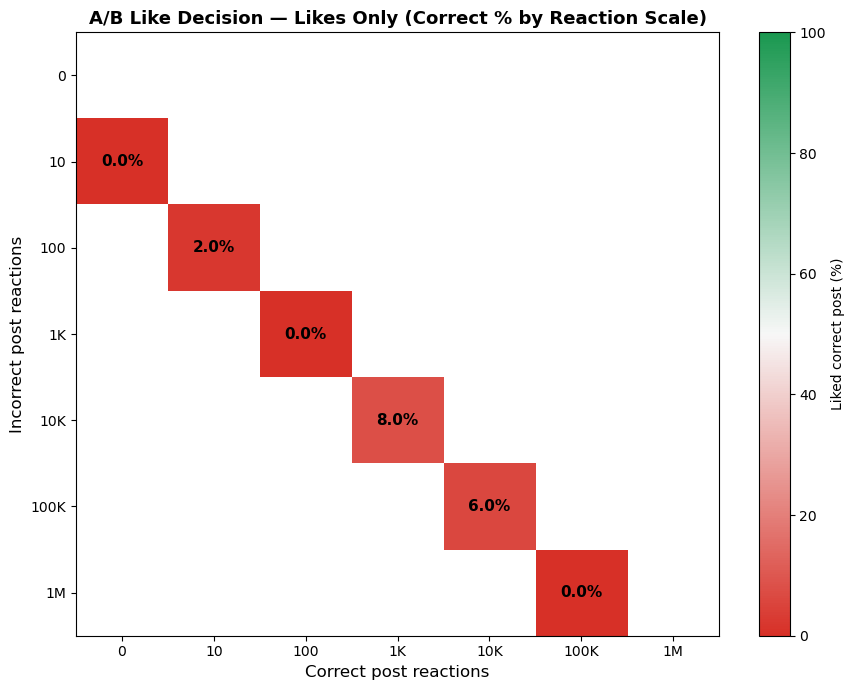

✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-4b/outputs/e1_results_likes_only_paired_grid.png


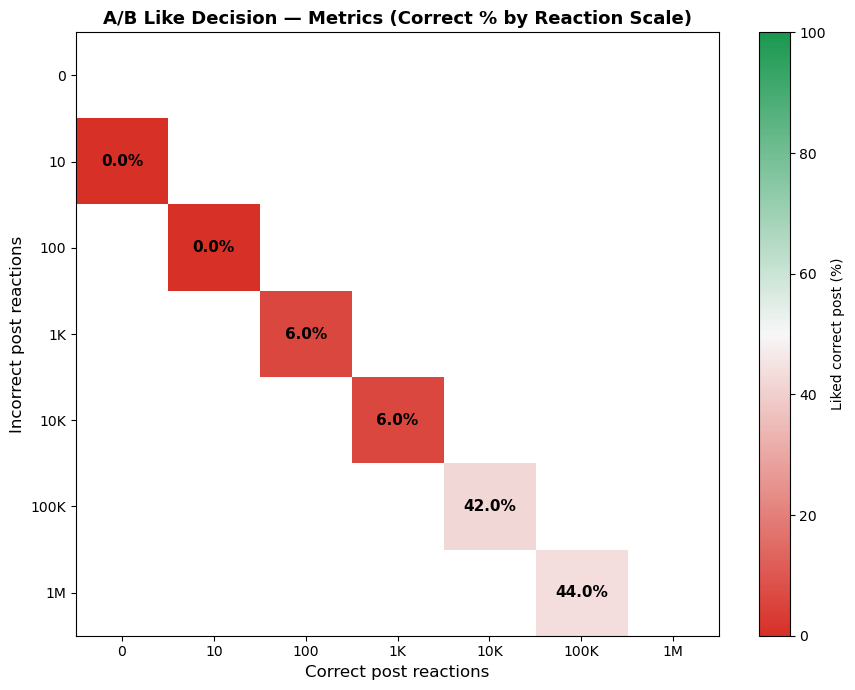

✅ Saved to: /home/jovyan/experiments/e1/qwen3-vl-4b/outputs/e1_results_metrics_paired_grid.png


In [31]:
from utils.e1_analysis_optimized import plot_ab_grid

# Likes only
plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_paired.json",
             title="A/B Like Decision — Likes Only (Correct % by Reaction Scale)")

# Metrics
plot_ab_grid(OUTPUT_DIR, "e1_results_metrics_paired.json", 
             title="A/B Like Decision — Metrics (Correct % by Reaction Scale)")



### Likes only

### Metrics

